# Notebook 3 — Otimização de Hiperparâmetros com TuRBO

Trust Region Bayesian Optimization. Mantém um GP local numa
região de confiança que expande/contrai conforme sucesso/fracasso.

Bugs corrigidos em relação ao código original:
1. EI não-normalizado: o código original passava best_f=Y_all.min() (Y bruto)
   para um GP treinado em Y normalizado → valores de aquisição incorretos.
   Corrigido: best_f é o mínimo normalizado.
2. Bounds errados: hidden_dim tinha lower bound = 0 (deveria ser 32).
3. Espaço de busca: refeito em [0, 1]^6 uniforme para consistência com
   normalize/unnormalize do BoTorch.
4. **LHS com scipy.stats.qmc:** substituição do LHS manual (permutação de linspace)
   pela implementação oficial, que garante cobertura Latin Hypercube.

In [1]:
import sys, os
sys.path.insert(0, "..")
os.makedirs("results", exist_ok=True)
os.makedirs("sim_cache", exist_ok=True)

import numpy as np
import torch
import json

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.utils.transforms import normalize, unnormalize
from gpytorch.mlls import ExactMarginalLogLikelihood
from scipy.stats import qmc

from common import (
    get_device, device_info, load_or_simulate, extract_dataset,
    make_objective, compute_metrics, encode_params,
    SIGMA_LEVELS, N_TRIALS, N_SEEDS, N_OSCILLATORS, LAM,
    T_SPAN, DT, N_TRAJS, SAVE_EVERY, N_EPOCHS_OBJ, PATIENCE_OBJ,
    SIM_CACHE_DIR, RESULTS_DIR, ACTIVATIONS, BATCH_SIZES,
)

DEVICE = get_device()
print(f"Device: {device_info(DEVICE)}")
# Nota: BoTorch usa CPU por padrão para o GP (float64); o treino da HNN usa DEVICE

Device: CUDA — NVIDIA GeForce RTX 4090 (25.3 GB)


In [2]:
# ── Espaço de busca em [0, 1]^6 ──────────────────────────────────────────────
#  x[0] → lr           log-uniform [1e-4, 1e-2]
#  x[1] → hidden_dim   inteiro [32, 256]
#  x[2] → n_layers     inteiro [1, 4]
#  x[3] → activation   índice [0, 3]
#  x[4] → batch_size   índice [0, 3]
#  x[5] → weight_decay log-uniform [1e-6, 1e-2]

UNIT_BOUNDS = torch.zeros(2, 6, dtype=torch.float64)
UNIT_BOUNDS[1] = 1.0   # todos em [0, 1]


def decode_turbo(x: torch.Tensor) -> dict:
    """Decodifica vetor em [0, 1]^6 para hiperparâmetros reais."""
    v = x.double().numpy()
    v = np.clip(v, 0.0, 1.0)
    lr = float(np.exp(np.log(1e-4) + v[0] * (np.log(1e-2) - np.log(1e-4))))
    hd = int(round(32.0 + v[1] * (256.0 - 32.0)))
    nl = int(round(1.0  + v[2] * 3.0))
    ai = int(round(v[3] * 3.0))
    bi = int(round(v[4] * 3.0))
    wd = float(np.exp(np.log(1e-6) + v[5] * (np.log(1e-2) - np.log(1e-6))))
    return {
        "lr":           float(np.clip(lr, 1e-4, 1e-2)),
        "hidden_dim":   int(np.clip(hd, 32, 256)),
        "n_layers":     int(np.clip(nl, 1, 4)),
        "activation":   ACTIVATIONS[int(np.clip(ai, 0, 3))],
        "batch_size":   BATCH_SIZES[int(np.clip(bi, 0, 3))],
        "weight_decay": float(np.clip(wd, 1e-6, 1e-2)),
    }


class TuRBOState:
    """Estado da trust region do TuRBO."""
    def __init__(self, dim: int):
        self.dim               = dim
        self.length            = 0.8
        self.length_min        = 0.5 ** 7
        self.length_max        = 1.6
        self.failure_counter   = 0
        self.failure_tolerance = max(4, dim)
        self.success_counter   = 0
        self.success_tolerance = 10
        self.best_value        = float("inf")
        self.restart_triggered = False

    def update(self, new_value: float):
        if new_value < self.best_value - 1e-3 * abs(self.best_value):
            self.success_counter += 1
            self.failure_counter  = 0
        else:
            self.failure_counter += 1
            self.success_counter  = 0

        if self.success_counter >= self.success_tolerance:
            self.length = min(self.length * 2.0, self.length_max)
            self.success_counter = 0
        if self.failure_counter >= self.failure_tolerance:
            self.length /= 2.0
            self.failure_counter = 0

        self.best_value = min(self.best_value, new_value)
        if self.length < self.length_min:
            self.restart_triggered = True

In [3]:
def run_turbo(objective_fn, n_trials: int, n_init: int = 10, seed: int = 42) -> dict:
    """
    Executa TuRBO e retorna histórico e melhores resultados.

    Correções vs. código original:
    - LHS via scipy.stats.qmc (cobertura correta)
    - Y normalizado para GP e para best_f do EI
    - Bounds para hidden_dim corrigidos (32, não 0)
    - Uso de qLogExpectedImprovement (numericamente mais estável que qEI)
    """
    assert 0 < n_init < n_trials

    torch.manual_seed(seed)
    dim = 6

    # Amostragem inicial via Latin Hypercube (scipy qmc)
    sampler = qmc.LatinHypercube(d=dim, seed=seed)
    X_init = torch.tensor(sampler.random(n=n_init), dtype=torch.float64)   # (n_init, 6)

    Y_init = torch.tensor(
        [objective_fn(decode_turbo(x)) for x in X_init],
        dtype=torch.float64,
    ).unsqueeze(-1)   # (n_init, 1)

    X_all = X_init.clone()
    Y_all = Y_init.clone()

    state = TuRBOState(dim)
    state.best_value = float(Y_all.min())

    history: list[float]  = Y_init.squeeze().tolist()
    all_params: list[dict] = [decode_turbo(x) for x in X_init]
    best_par  = decode_turbo(X_init[int(Y_init.argmin())])

    # ── Loop principal TuRBO ─────────────────────────────────────────────────
    while len(history) < n_trials:
        # Normalização de Y (média=0, std=1) para o GP
        Y_mean  = Y_all.mean()
        Y_std   = Y_all.std().clamp(min=1e-6)
        Y_norm  = (Y_all - Y_mean) / Y_std
        best_f_norm = float(Y_norm.min())

        # Trust region: centrada no melhor ponto, ponderada por importância de features
        best_idx = int(Y_all.argmin())
        x_center = X_all[best_idx]                                     # (6,)
        weights  = (X_all - x_center).abs().mean(0)
        weights  = weights / weights.mean().clamp(min=1e-8)

        tr_lb = torch.clamp(x_center - weights * state.length / 2, 0.0, 1.0)
        tr_ub = torch.clamp(x_center + weights * state.length / 2, 0.0, 1.0)
        # Garantir lb < ub em cada dimensão
        tr_lb, tr_ub = torch.min(tr_lb, tr_ub), torch.max(tr_lb, tr_ub)
        tr_ub = tr_ub + 1e-6   # afastar se colapsar

        # Fit do GP na trust region (usando X em [0,1] já normalizado)
        gp  = SingleTaskGP(X_all, Y_norm)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)

        # Aquisição qLogEI (mais estável numericamente que qEI original)
        acqf = qLogExpectedImprovement(gp, best_f=best_f_norm)
        bounds_tr = torch.stack([tr_lb, tr_ub])   # (2, 6)

        candidate, _ = optimize_acqf(
            acqf,
            bounds=bounds_tr,
            q=1,
            num_restarts=5,
            raw_samples=128,
        )

        x_new  = candidate.detach().squeeze(0)   # (6,)
        params = decode_turbo(x_new)
        y_new  = float(objective_fn(params))

        state.update(y_new)
        X_all = torch.cat([X_all, x_new.unsqueeze(0)])
        Y_all = torch.cat([Y_all, torch.tensor([[y_new]], dtype=torch.float64)])
        history.append(y_new)
        all_params.append(params)

        if y_new < state.best_value:
            best_par = params

        if state.restart_triggered:
            state = TuRBOState(dim)
            state.best_value = float(Y_all.min())

    return {
        "best_value":         float(min(history)),
        "best_params":        best_par,
        "history":            history,
        "all_params_encoded": [encode_params(p) for p in all_params],
        "metrics":            compute_metrics(history),
    }

In [4]:
results = {}

for sigma_J in SIGMA_LEVELS:
    results[str(sigma_J)] = {}
    print(f"\n{'='*50}")
    print(f"sigma_J = {sigma_J}")
    print(f"{'='*50}")

    for seed in range(N_SEEDS):
        print(f"  Seed {seed}/{N_SEEDS-1}", end=" | ", flush=True)

        J_np, states = load_or_simulate(
            SIM_CACHE_DIR, N_OSCILLATORS, sigma_J, LAM,
            N_TRAJS, T_SPAN, DT, DEVICE, seed, SAVE_EVERY,
        )
        X, Y = extract_dataset(states, J_np, LAM)
        print(f"Dataset: {len(X):,} amostras", end=" | ", flush=True)

        objective_fn = make_objective(X, Y, N_OSCILLATORS, DEVICE,
                                      n_epochs=N_EPOCHS_OBJ,
                                      patience=PATIENCE_OBJ)
        res = run_turbo(objective_fn, N_TRIALS, n_init=10, seed=seed)
        results[str(sigma_J)][str(seed)] = res

        best = res["best_value"]
        t10  = res["metrics"]["t10"]
        print(f"Best val_loss={best:.4e}, t10={t10}", flush=True)

os.makedirs(RESULTS_DIR, exist_ok=True)
out_path = os.path.join(RESULTS_DIR, "turbo_results.json")
with open(out_path, "w") as f:
    json.dump({"method": "turbo", "results": results}, f, indent=2)

print(f"\nResultados salvos em: {out_path}")


sigma_J = 0.0
  Seed 0/2 | 

Dataset: 40,000 amostras | 

Best val_loss=7.3574e-06, t10=28


  Seed 1/2 | 

Dataset: 40,000 amostras | 

...

Best val_loss=6.0478e-04, t10=35


  Seed 2/2 | 

Dataset: 40,000 amostras | 

Best val_loss=1.7246e-03, t10=36



Resultados salvos em: results/turbo_results.json


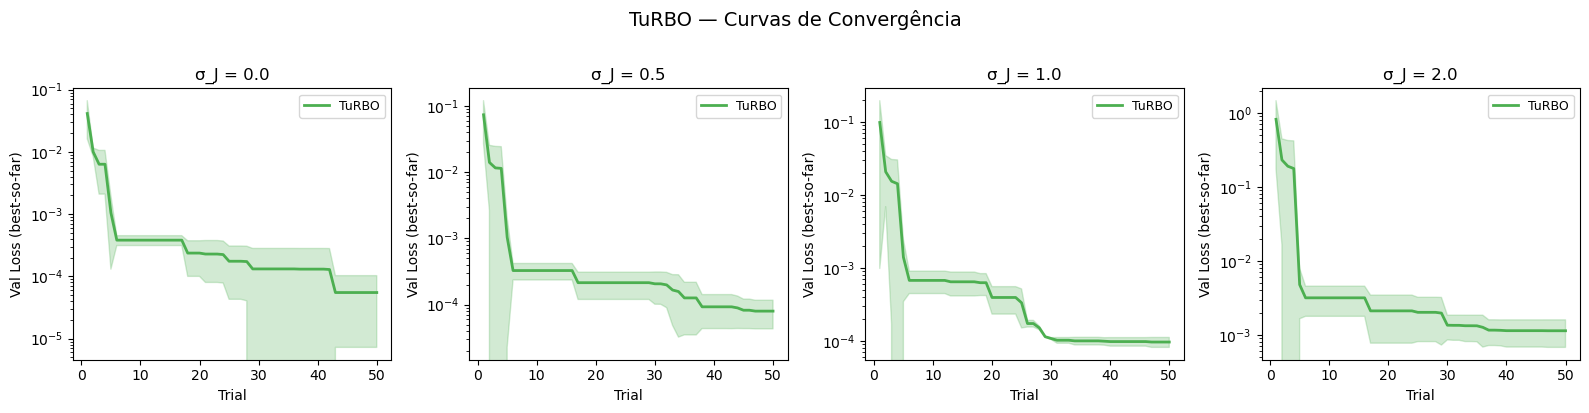

Plot salvo.


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SIGMA_LEVELS), figsize=(16, 4), sharey=False)
color = "#4CAF50"

for ax, sigma_J in zip(axes, SIGMA_LEVELS):
    histories = [
        np.minimum.accumulate(results[str(sigma_J)][str(s)]["history"])
        for s in range(N_SEEDS)
    ]
    max_len = max(len(h) for h in histories)
    padded = [np.pad(h, (0, max_len - len(h)), mode="edge") for h in histories]
    mean = np.mean(padded, axis=0)
    std  = np.std(padded, axis=0)
    trials = np.arange(1, len(mean) + 1)

    ax.plot(trials, mean, color=color, lw=2, label="TuRBO")
    ax.fill_between(trials, mean - std, mean + std, alpha=0.25, color=color)
    ax.set_title(f"σ_J = {sigma_J}", fontsize=12)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val Loss (best-so-far)")
    ax.set_yscale("log")
    ax.legend(fontsize=9)

plt.suptitle("TuRBO — Curvas de Convergência", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "turbo_convergence.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Plot salvo.")